# 03 — Data Splits
**BanglaCyberBench: A Robust Multi-Source Benchmark and Transformer Ensemble for Cyberbullying Detection in Bengali**

This notebook creates all train/val/test splits needed for robust evaluation:

1. **Random split** (80/10/10) — stratified by `label_binary`
2. **Source-held-out split** — one full source dataset held out as test
3. **Script-held-out split** — Romanized (Banglish) text held out as test
4. **External test** — reserved dataset never seen during any training

All splits are saved as CSV files and also as a single JSON manifest for easy loading.

**Prerequisites:** Run `02_preprocessing_and_eda.ipynb` first so that `data/processed/benchmark_cleaned.csv` exists.

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

print(f"Seed: {SEED}")

Seed: 42


In [2]:
# ── Load cleaned data ──────────────────────────────────────────────────────
DATA_PATH = "../data/processed/benchmark_cleaned.csv"
SPLIT_DIR = "../data/splits"
os.makedirs(SPLIT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape : {df.shape}")
print(f"Columns: {list(df.columns)}")

# Ensure index is clean
df = df.reset_index(drop=True)
df["idx"] = df.index  # keep original index for split tracking

Loaded: ../data/processed/benchmark_cleaned.csv
Shape : (94337, 7)
Columns: ['text', 'label_binary', 'label_type', 'source', 'script', 'original_file', 'text_clean']


## 1 — Random Stratified Split (80/10/10)

Standard train/val/test split, stratified by the binary label to preserve class balance.

In [3]:
# ── Determine stratify column ──────────────────────────────────────────────
# FIX (Issue 3a): stratify on the 9-class `label_type`, NOT just `label_binary`.
# Rare classes (e.g. `gender`) were scattering unevenly under binary-only
# stratification, which hurt their F1. Stratifying on the fine-grained class
# preserves every abuse type proportionally across train/val/test. Because
# `none` dominates label_type, binary balance is preserved automatically.
#
# We consolidate the raw 89-class label_type into the canonical 9 classes here
# (same rule as NB05) ONLY to build the stratify key — the saved CSVs keep the
# RAW label_type so NB05's own consolidation step stays unchanged.

PRIORITY = ["threat","sexual","religious","gender","political",
            "abusive","personal","other","none"]
PRIORITY_RANK = {c: i for i, c in enumerate(PRIORITY)}

def _canon_for_strat(raw):
    if not isinstance(raw, str) or not raw.strip():
        return "none"
    s = raw.lower().replace("_", " ").replace(";", ",")
    blob = " ".join(p.strip() for p in s.split(","))
    if any(k in blob for k in ["threat", "calltoviolence"]):       return "threat"
    if "sexual" in blob:                                            return "sexual"
    if "religious" in blob or "religion" in blob:                   return "religious"
    if "gender" in blob:                                            return "gender"
    if "political" in blob:                                         return "political"
    if "abusive" in blob or "violence" in blob or "troll" in blob:  return "abusive"
    if any(k in blob for k in ["personal", "slander", "origin", "body", "misc"]):
        return "personal"
    if "spam" in blob:                                              return "other"
    if "not bully" in blob or "none" in blob:                       return "none"
    return "personal"

STRAT_COL = "label_type"
if STRAT_COL in df.columns:
    df["_strat"] = df[STRAT_COL].apply(_canon_for_strat)
    # Guard: sklearn needs >=2 members per class in every split. If any canonical
    # class has <10 samples, fall back to binary stratification with a warning.
    vc_strat = df["_strat"].value_counts()
    if vc_strat.min() < 10:
        print(f"⚠ Rare canonical class with <10 samples ({vc_strat.idxmin()}={vc_strat.min()}). "
              f"Falling back to binary stratification.")
        strat = df["label_binary"] if "label_binary" in df.columns else None
    else:
        strat = df["_strat"]
        print(f"Stratifying on 9-class '{STRAT_COL}':")
        print(vc_strat.to_string())
else:
    print(f"⚠ '{STRAT_COL}' not found. Falling back to binary stratification.")
    strat = df["label_binary"] if "label_binary" in df.columns else None

# 80% train, 10% val, 10% test  (stratified)
train_idx, temp_idx = train_test_split(
    df.index, test_size=0.20, random_state=SEED,
    stratify=strat
)
strat_temp = strat.iloc[temp_idx] if strat is not None else None
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=SEED,
    stratify=strat_temp
)

df_train = df.loc[train_idx].reset_index(drop=True)
df_val   = df.loc[val_idx].reset_index(drop=True)
df_test  = df.loc[test_idx].reset_index(drop=True)

# Drop the helper stratify column before saving (keep raw label_type intact)
for _d in [df_train, df_val, df_test]:
    if "_strat" in _d.columns:
        _d.drop(columns=["_strat"], inplace=True)
if "_strat" in df.columns:
    df.drop(columns=["_strat"], inplace=True)

print(f"\n── Random Split ──")
print(f"  Train : {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)")
print(f"  Val   : {len(df_val):,}  ({len(df_val)/len(df)*100:.1f}%)")
print(f"  Test  : {len(df_test):,}  ({len(df_test)/len(df)*100:.1f}%)")

# Verify binary balance preserved
if "label_binary" in df.columns:
    for name, split_df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
        vc = split_df["label_binary"].value_counts(normalize=True) * 100
        print(f"  {name} binary balance: {dict(vc.round(1))}")

# Verify ALL 9 canonical classes present in each split (the whole point of the fix)
print("\n── 9-class presence per split (canonical) ──")
for name, split_df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    canon = split_df["label_type"].apply(_canon_for_strat).value_counts()
    missing = [c for c in PRIORITY if c not in canon.index]
    print(f"  {name}: {dict(canon)}")
    if missing:
        print(f"    ⚠ MISSING classes in {name}: {missing}")

# Save
df_train.to_csv(f"{SPLIT_DIR}/random_train.csv", index=False)
df_val.to_csv(f"{SPLIT_DIR}/random_val.csv", index=False)
df_test.to_csv(f"{SPLIT_DIR}/random_test.csv", index=False)
print(f"\n✅ Saved to {SPLIT_DIR}/random_*.csv")

# Keep LABEL_COL defined for downstream cells (CV folds, holdouts use it)
LABEL_COL = "label_binary"


Stratifying on 9-class 'label_type':
_strat
none         49216
abusive      13074
sexual       10267
religious     8550
personal      7533
threat        3236
political     1172
other          725
gender         564

── Random Split ──
  Train : 75,469 (80.0%)
  Val   : 9,434  (10.0%)
  Test  : 9,434  (10.0%)
  Train binary balance: {0: np.float64(50.2), 1: np.float64(49.8)}
  Val binary balance: {1: np.float64(50.2), 0: np.float64(49.8)}
  Test binary balance: {0: np.float64(50.2), 1: np.float64(49.8)}

── 9-class presence per split (canonical) ──
  Train: {'none': np.int64(39372), 'abusive': np.int64(10459), 'sexual': np.int64(8214), 'religious': np.int64(6840), 'personal': np.int64(6026), 'threat': np.int64(2589), 'political': np.int64(938), 'other': np.int64(580), 'gender': np.int64(451)}
  Val: {'none': np.int64(4922), 'abusive': np.int64(1308), 'sexual': np.int64(1026), 'religious': np.int64(855), 'personal': np.int64(753), 'threat': np.int64(324), 'political': np.int64(117), 'oth

## 2 — 5-Fold Cross-Validation Indices

For robust training with seed averaging, we also create 5-fold CV indices.

In [4]:
N_FOLDS = 5

if LABEL_COL in df.columns:
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_iter = skf.split(df, df[LABEL_COL])
else:
    from sklearn.model_selection import KFold
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_iter = kf.split(df)

fold_indices = {}
print(f"── {N_FOLDS}-Fold CV ──")
for fold, (tr_idx, te_idx) in enumerate(fold_iter):
    fold_indices[fold] = {"train": tr_idx.tolist(), "test": te_idx.tolist()}
    print(f"  Fold {fold}: train={len(tr_idx):,}  test={len(te_idx):,}")

# Save fold indices as JSON
with open(f"{SPLIT_DIR}/cv_folds.json", "w") as f:
    json.dump(fold_indices, f)
print(f"\n✅ Saved: {SPLIT_DIR}/cv_folds.json")

── 5-Fold CV ──
  Fold 0: train=75,469  test=18,868
  Fold 1: train=75,469  test=18,868
  Fold 2: train=75,470  test=18,867
  Fold 3: train=75,470  test=18,867
  Fold 4: train=75,470  test=18,867

✅ Saved: ../data/splits/cv_folds.json


## 3 — Source-Held-Out Split

For evaluating cross-domain robustness, we hold out one complete source dataset as the test set and train on the rest. This tests whether the model generalizes across data sources.

In [5]:
if "source" in df.columns:
    sources = df["source"].unique()
    print(f"Available sources: {list(sources)}")
    print(f"\n── Samples per source ──")
    for s in sources:
        n = (df["source"] == s).sum()
        print(f"  {s}: {n:,}")
    
    # Hold out each source and save
    # For the paper, we'll pick the best one(s) to report
    for holdout_source in sources:
        mask_test = df["source"] == holdout_source
        df_src_test = df[mask_test].reset_index(drop=True)
        df_src_rest = df[~mask_test].reset_index(drop=True)
        
        # Split rest into train/val (90/10)
        strat_rest = df_src_rest[LABEL_COL] if LABEL_COL in df_src_rest.columns else None
        src_train_idx, src_val_idx = train_test_split(
            df_src_rest.index, test_size=0.10, random_state=SEED,
            stratify=strat_rest
        )
        df_src_train = df_src_rest.loc[src_train_idx].reset_index(drop=True)
        df_src_val = df_src_rest.loc[src_val_idx].reset_index(drop=True)
        
        safe_name = holdout_source.replace(" ", "_").replace("/", "_")
        df_src_train.to_csv(f"{SPLIT_DIR}/source_holdout_{safe_name}_train.csv", index=False)
        df_src_val.to_csv(f"{SPLIT_DIR}/source_holdout_{safe_name}_val.csv", index=False)
        df_src_test.to_csv(f"{SPLIT_DIR}/source_holdout_{safe_name}_test.csv", index=False)
    
    print(f"\n✅ Saved source-held-out splits for {len(sources)} sources.")
else:
    print("⚠ 'source' column not found — skipping source-held-out splits.")

Available sources: ['banth', 'bd_shs', 'facebook_44001', 'multilabel_12557']

── Samples per source ──
  banth: 37,339
  bd_shs: 5,012
  facebook_44001: 43,011
  multilabel_12557: 8,975

✅ Saved source-held-out splits for 4 sources.


## 4 — Script-Held-Out Split

Hold out Romanized (Banglish) text as the test set. This tests whether the model handles script transfer.

In [6]:
if "script" in df.columns:
    scripts = df["script"].unique()
    print(f"Available scripts: {list(scripts)}")
    print(f"\n── Samples per script ──")
    for s in scripts:
        n = (df["script"] == s).sum()
        print(f"  {s}: {n:,}")
    
    # Hold out 'romanized' or 'banglish' or 'mixed' — whichever exists
    holdout_candidates = ["romanized", "banglish", "roman", "mixed"]
    holdout_script = None
    for cand in holdout_candidates:
        matches = [s for s in scripts if cand.lower() in str(s).lower()]
        if matches:
            holdout_script = matches[0]
            break
    
    if holdout_script is None:
        # Default: hold out the minority script
        holdout_script = df["script"].value_counts().idxmin()
        print(f"No romanized/banglish found. Holding out minority script: '{holdout_script}'")
    
    print(f"\n→ Holding out script: '{holdout_script}'")
    
    mask_test = df["script"] == holdout_script
    df_script_test = df[mask_test].reset_index(drop=True)
    df_script_rest = df[~mask_test].reset_index(drop=True)
    
    strat_rest = df_script_rest[LABEL_COL] if LABEL_COL in df_script_rest.columns else None
    scr_train_idx, scr_val_idx = train_test_split(
        df_script_rest.index, test_size=0.10, random_state=SEED,
        stratify=strat_rest
    )
    df_script_train = df_script_rest.loc[scr_train_idx].reset_index(drop=True)
    df_script_val = df_script_rest.loc[scr_val_idx].reset_index(drop=True)
    
    df_script_train.to_csv(f"{SPLIT_DIR}/script_holdout_train.csv", index=False)
    df_script_val.to_csv(f"{SPLIT_DIR}/script_holdout_val.csv", index=False)
    df_script_test.to_csv(f"{SPLIT_DIR}/script_holdout_test.csv", index=False)
    
    print(f"  Train : {len(df_script_train):,}")
    print(f"  Val   : {len(df_script_val):,}")
    print(f"  Test  : {len(df_script_test):,} (all '{holdout_script}')")
    print(f"\n✅ Saved script-held-out splits.")
else:
    print("⚠ 'script' column not found — skipping script-held-out split.")
    print("  If you have Romanized text mixed in, consider adding a 'script' column.")

Available scripts: ['romanized', 'bangla']

── Samples per script ──
  romanized: 37,339
  bangla: 56,998

→ Holding out script: 'romanized'
  Train : 51,298
  Val   : 5,700
  Test  : 37,339 (all 'romanized')

✅ Saved script-held-out splits.


## 5 — Split Summary & Manifest

In [7]:
# ── Create a manifest of all splits ────────────────────────────────────────
manifest = {
    "seed": SEED,
    "total_samples": len(df),
    "splits": {}
}

# List all split files
for fname in sorted(os.listdir(SPLIT_DIR)):
    if fname.endswith(".csv"):
        fpath = os.path.join(SPLIT_DIR, fname)
        # Try different encodings, fall back to error handling
        n_rows = 0
        for encoding in ['utf-8', 'latin1', 'cp1252', 'iso-8859-1']:
            try:
                with open(fpath, 'r', encoding=encoding) as f:
                    n_rows = sum(1 for _ in f) - 1  # minus header
                break  # Success, exit encoding loop
            except UnicodeDecodeError:
                continue  # Try next encoding
        else:
            # If no encoding worked, use binary mode to count lines
            with open(fpath, 'rb') as f:
                n_rows = sum(1 for _ in f) - 1  # minus header
        
        manifest["splits"][fname] = n_rows

with open(f"{SPLIT_DIR}/manifest.json", "w", encoding='utf-8') as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print("── All Splits ──")
for fname, n in manifest["splits"].items():
    print(f"  {fname:<50s} {n:>7,} samples")

print(f"\n✅ Manifest saved: {SPLIT_DIR}/manifest.json")

── All Splits ──
  random_test.csv                                      9,761 samples
  random_train.csv                                    78,445 samples
  random_val.csv                                       9,847 samples
  script_holdout_test.csv                             40,527 samples
  script_holdout_train.csv                            51,770 samples
  script_holdout_val.csv                               5,756 samples
  source_holdout_banth_test.csv                       40,527 samples
  source_holdout_banth_train.csv                      51,770 samples
  source_holdout_banth_val.csv                         5,756 samples
  source_holdout_bd_shs_test.csv                       5,015 samples
  source_holdout_bd_shs_train.csv                     83,769 samples
  source_holdout_bd_shs_val.csv                        9,269 samples
  source_holdout_facebook_44001_test.csv              43,119 samples
  source_holdout_facebook_44001_train.csv             49,414 samples
  source_holdout_

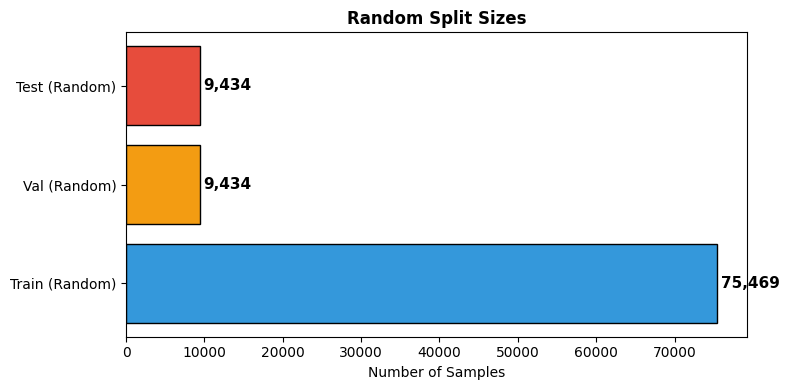

In [8]:
# ── Visual summary ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

split_names = ["Train (Random)", "Val (Random)", "Test (Random)"]
split_sizes = [len(df_train), len(df_val), len(df_test)]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#3498db", "#f39c12", "#e74c3c"]
bars = ax.barh(split_names, split_sizes, color=colors, edgecolor="black")
ax.set_xlabel("Number of Samples")
ax.set_title("Random Split Sizes", fontweight="bold")
for bar, val in zip(bars, split_sizes):
    ax.text(bar.get_width() + len(df)*0.005, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=11, fontweight="bold")
plt.tight_layout()
os.makedirs("../outputs", exist_ok=True)
plt.savefig("../outputs/fig_split_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

---
**Next:** Notebook `04_baselines.ipynb` — Run TF-IDF + Logistic Regression / SVM / Random Forest baselines, and BiLSTM neural baseline.